In [1]:
# --- Header ---
# Project: British Airways Data Science Simulation
# Task 2: Predictive Modeling of Customer Booking Behavior
# Author: [Edmund Eric Gah]

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


sns.set_theme(style="whitegrid")


df = pd.read_csv('customer_booking.csv', encoding='ISO-8859-1')

# Clean column names (removes extra spaces)
df.columns = df.columns.str.strip()

# Display first few rows to verify
print("Data loaded successfully!")
df.head()

Data loaded successfully!


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


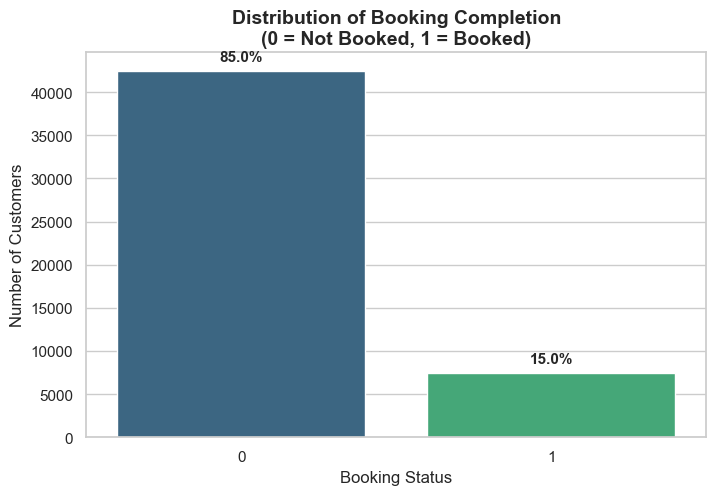

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

if 'df' in locals():
    df.columns = df.columns.str.strip() 
    

    plt.figure(figsize=(8, 5))
    
    ax = sns.countplot(x='booking_complete', data=df, palette='viridis', hue='booking_complete', legend=False)
    
   
    plt.title('Distribution of Booking Completion\n(0 = Not Booked, 1 = Booked)', fontsize=14, fontweight='bold')
    plt.xlabel('Booking Status', fontsize=12)
    plt.ylabel('Number of Customers', fontsize=12)

   
    total = len(df)
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

    plt.show()
else:
    print("Error: The dataframe 'df' is not defined. Please run Cell 1 first to load your data!")

In [14]:

day_map = {
    "Mon": 1, "Tue": 2, "Wed": 3, "Thu": 4, "Fri": 5, "Sat": 6, "Sun": 7
}
df["flight_day_num"] = df["flight_day"].map(day_map)

categorical_cols = ['sales_channel', 'trip_type']
df_final = pd.get_dummies(df.drop(columns=['route', 'booking_origin', 'flight_day']), 
                          columns=categorical_cols, 
                          drop_first=True)

print("Preprocessing Complete! Here are your features:")
print(df_final.columns.tolist())
df_final.head()

Preprocessing Complete! Here are your features:
['num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour', 'wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals', 'flight_duration', 'booking_complete', 'flight_day_num', 'sales_channel_Mobile', 'trip_type_OneWay', 'trip_type_RoundTrip']


,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,flight_day_num,sales_channel_Mobile,trip_type_OneWay,trip_type_RoundTrip
0,2,262,19,7,1,0,0,5.52,0,NaN,False,False,True
1,1,112,20,3,0,0,0,5.52,0,NaN,False,False,True
2,2,243,22,17,1,1,0,5.52,0,NaN,False,False,True
3,1,96,31,4,0,0,1,5.52,0,NaN,False,False,True
4,2,68,22,15,1,0,1,5.52,0,NaN,False,False,True


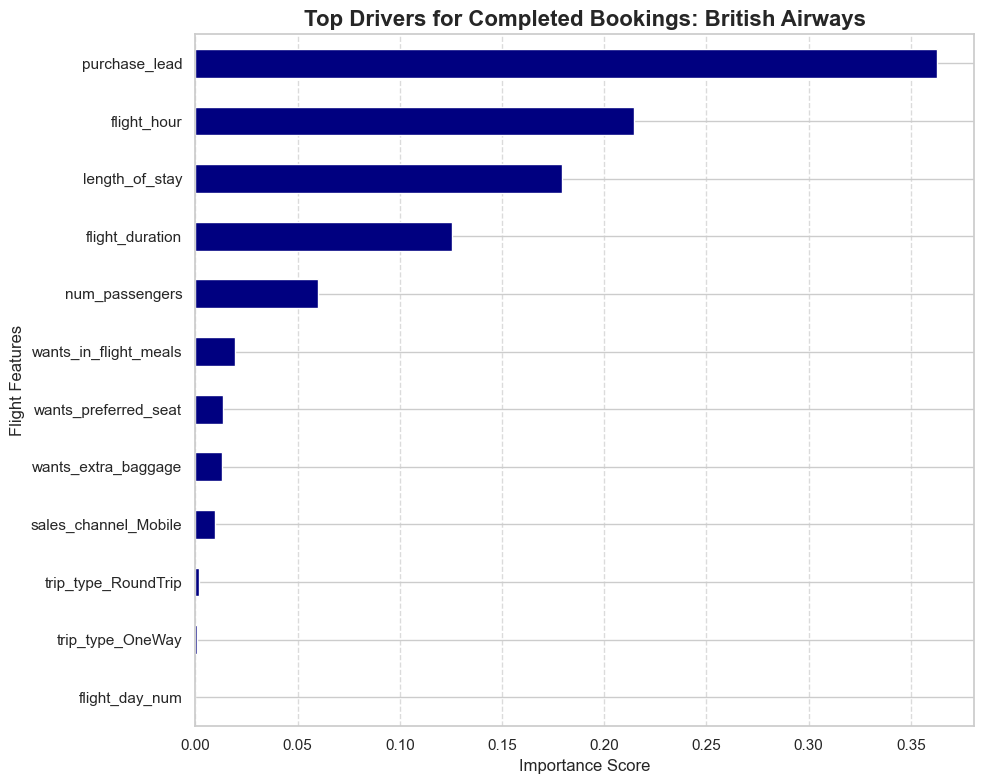

Model Performance: 84.23% Accuracy


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X = df_final.drop(columns=['booking_complete'])
y = df_final['booking_complete']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# I decided to use random forest here
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='navy')
plt.title('Top Drivers for Completed Bookings: British Airways', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Flight Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('feature_importance.png', bbox_inches='tight', dpi=300)
plt.show()
plt.show()

#Checking for output accuracy
y_pred = model.predict(X_test)
print(f"Model Performance: {accuracy_score(y_test, y_pred)*100:.2f}% Accuracy")